In [23]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as con
from helper import *

In [ ]:
v_c = np.array([218, -119, 21])

num = int(1e5)
np.random.seed(0)
vel = np.random.multivariate_normal((0, 0, 0), np.diag([167**2]*3), num)
#spd = speed(vel)

vel += v_c #solar frame vel at asymptotic infinity

rho = []
for str_num in range(1, num+1):
    rho.append(get_density(str_num))

rho = np.array(rho)

In [ ]:
import astropy.constants as acon

def grav(x):
    return - acon.G.value * 1e-9 * acon.M_sun.value / 149600000

def v_inf(v, t):
    r = np.array([[np.cos(t), np.sin(t), 0]]) # in km
    d = np.sqrt(np.sum(v*v) + 2 * grav(r))

    vi = d * d * v \
        -  d * r / speed(r) * grav(r) \
        - d * v * (np.dot(v, r.T / speed(r)))
    
    vi = vi / (d*d - grav(r) - d * np.dot(v, r.T / speed(r)))
    
    return vi

def func(v, vi, t):
    '''
    Phi = 887.13
    
    u = np.linalg.norm(vi)
    rhat = np.array([1, 0, 0])
    vdotr = np.linalg.norm(v * rhat)
    D = u**2 + Phi - u*vdotr
    
    ratio = np.abs(Phi / D)
    
    if ratio > 1:
        return np.zeros(3) + np.inf
    '''
    return (v_inf(v, t) - vi).T[:, 0]

def jacobianClosed(v, Phi, rhat = np.array([1, 0, 0])):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    v = np.asarray(v, dtype=float)
    v2 = speed(v)
    u = np.sqrt(v2**2 - 2*Phi)
    vdotr = speed(v * rhat)
    D = u**2 + Phi - u*vdotr
    return (1 - (Phi/D)**2)

In [22]:
v = []
t = 0
Phi = 887.13
for vi in vel:
    root = np.array([25, 25, 25])
    x0 = np.array([25, 25, 25])

    i = 0
    ma = 3
    while ma != -2:
        root = fsolve(func, x0, args=(vi, t))
        
        if np.min(x0 == root) == 0 and jacobianClosed([root], Phi) > 0:
            break
        
        root = np.array([25, 25, 25])
        if ma <= 0:
            x0 = -x0
            ma -= 1
            continue

        x0[i] = - x0[i]
        
        i += 1
        if i >= ma:
            ma -= 1
            i = 0
        
        root = np.array([25, 25, 25])

    v.append(root)
v = np.array(v)

mask = np.abs(v) == [25, 25, 25]
mask = np.sum(mask, axis=1).astype(bool)
v = v[~mask]
dens = rho[~mask]

new_dens = dens / jacobianClosed(v, Phi)

NameError: name 'vel' is not defined

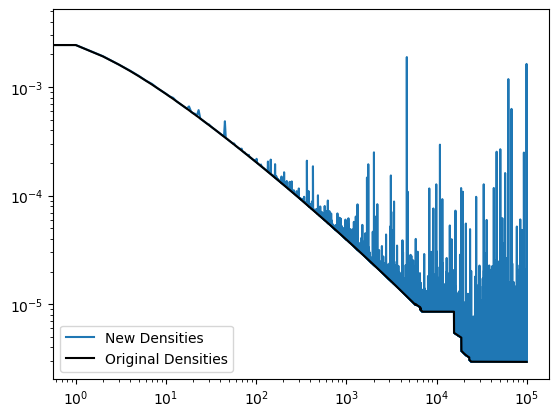

In [8]:
plt.clf()
#plt.scatter(np.arange(0, num, 1),new_dens, label ="New Densities", s = 3)
plt.plot(new_dens, label ="New Densities")

plt.loglog(dens, label="Original Densities", c="black")
plt.legend()

''

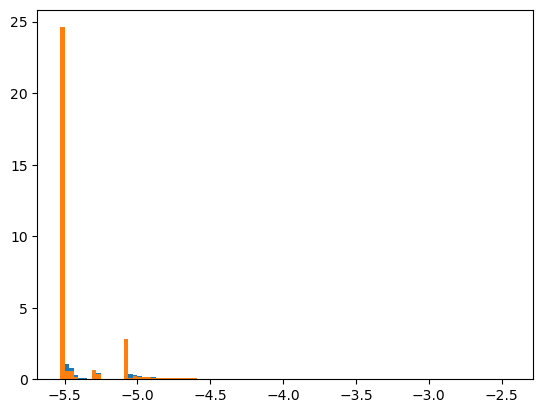

In [ ]:
plt.clf()

prev = np.log10(rho)
curr = np.log10(new_dens)

mini = min(prev.min(), curr.min())
maxi = max(prev.max(), curr.max())

bins = np.linspace(mini, maxi, 100)

#bins = 80

prev_his = np.histogram(prev, bins, density = True)
curr_his = np.histogram(curr, bins, density = True)

plt.plot(prev_his[1][1:], prev_his[0])
plt.semilogy(curr_his[1][1:], curr_his[0])

[]

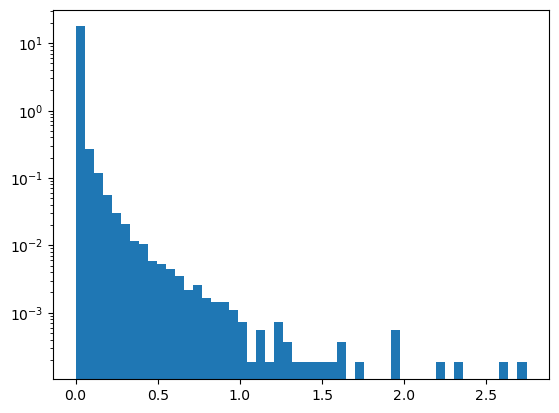

In [23]:
A = new_dens / dens
plt.hist(np.log10(A), 50, density = True)
plt.semilogy()

C:\Users\Shaurya\AppData\Local\Temp\ipykernel_39576\2961119056.py:8: RuntimeWarning: invalid value encountered in sqrt
  d = np.sqrt(np.sum(v*v) + 2 * grav(r))
C:\Users\Shaurya\AppData\Local\Temp\ipykernel_39576\1273198626.py:18: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root = fsolve(func, [-25,-25, -25], args=(vi, t))
C:\Users\Shaurya\AppData\Local\Temp\ipykernel_39576\1273198626.py:18: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  root = fsolve(func, [-25,-25, -25], args=(vi, t))


<Figure size 640x480 with 0 Axes>

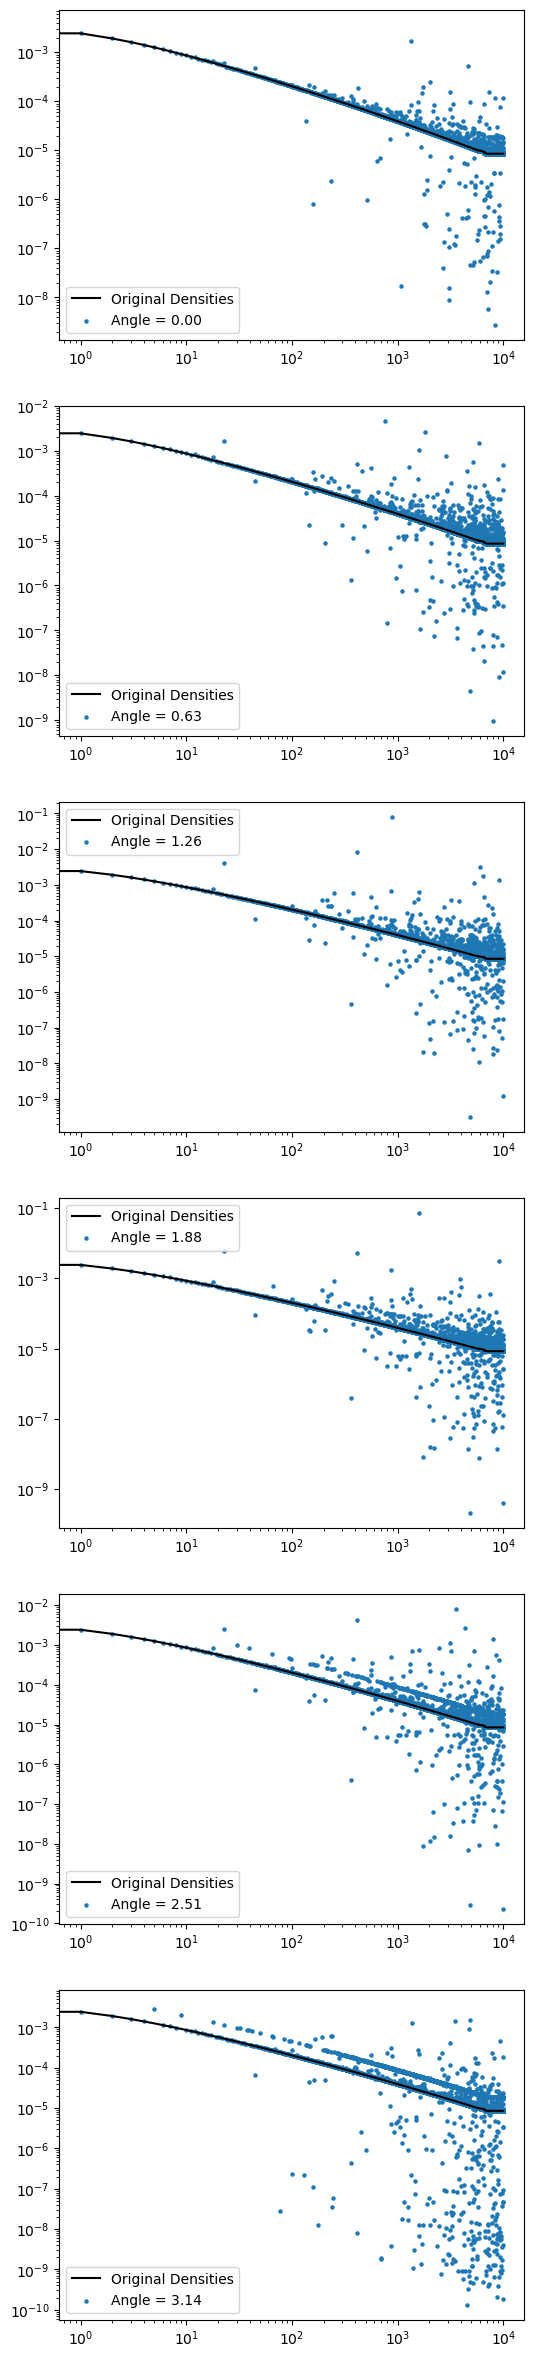

In [ ]:
def func(v, vi, t):
    return (v_inf(v, t) - vi).T[:, 0]

Phi = 887.13

plt.clf()

num_angles = 6
fig, ax = plt.subplots(num_angles, 1, figsize=(6, 5 * num_angles))


i = 0
for t in np.linspace(0, np.pi, num_angles):
    axe = ax[i]
    axe.loglog(rho, label="Original Densities", c="black")
    v = []
    for vi in vel:
        root = fsolve(func, [-25,-25, -25], args=(vi, t))
        v.append(root)
    v = np.array(v)

    new_dens = rho / jacobianClosed(v, Phi)
    axe.scatter(np.arange(0, num, 1), new_dens, label =f"Angle = {t:.2f}", s = 5)
    #plt.plot(new_dens, label ="New Densities")
    axe.legend()
    i += 1

In [11]:
# Plot histograms of this density distribution, before and after. Use log scaling to see the differences.